# Data Project
Authors: Alessio Carnevale, Manuel Cattoni, Carlo Schillaci

# Load the Dataset

In [1]:
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
from dotenv import load_dotenv
load_dotenv() 

PARQUET = "s3://data-project-supsi-bucket/data.parquet"

In [3]:
# Configure S3 once
con = duckdb.connect("project.duckdb")
con.sql("INSTALL httpfs; LOAD httpfs;")

# Peek at structure
con.sql(f"DESCRIBE SELECT * FROM read_parquet('{PARQUET}')").df()

,column_name,column_type,null,key,default,extra
0,id,VARCHAR,YES,None,None,None
1,title,VARCHAR,YES,None,None,None
2,abstract,VARCHAR,YES,None,None,None
3,keywords,VARCHAR[],YES,None,None,None
4,year,BIGINT,YES,None,None,None
5,authors,"STRUCT(id VARCHAR, ""name"" VARCHAR, org VARCHAR)[]",YES,None,None,None
6,references,VARCHAR[],YES,None,None,None
7,page_start,VARCHAR,YES,None,None,None
8,page_end,VARCHAR,YES,None,None,None
9,lang,VARCHAR,YES,None,None,None


In [4]:
# --- Build papers once, reuse everywhere ---

REBUILD_PAPERS = False  # set True only when you want to rebuild from S3

if REBUILD_PAPERS:
    con.sql("DROP TABLE IF EXISTS papers")

con.sql(f"""
CREATE TABLE IF NOT EXISTS papers AS
SELECT
    *,
    ARRAY_LENGTH(authors) AS n_authors,
    ARRAY_LENGTH(keywords) AS n_keywords,
    ARRAY_LENGTH("references") AS n_references,
    LENGTH(COALESCE(title, '')) AS title_len,
    LENGTH(COALESCE(abstract, '')) AS abstract_len,
    TRY_CAST(page_end AS BIGINT) - TRY_CAST(page_start AS BIGINT) AS page_count
FROM read_parquet('{PARQUET}')
""")

con.sql("SELECT COUNT(*) AS n_rows FROM papers").df()

,n_rows
0,5590897


In [5]:
asd = con.sql(f"""
SELECT abstract FROM papers
LIMIT 2
""").df()

asd = np.array(asd)

print(asd[1:][0][0])

The UCI version of the Rand Message Handling System (MH) is discussed, including important extensions. MH is a powerful user agent which operates in the ARPA Internet and UUCP environments. In addition to the basic functions provided by a user agent, such as reading and sending mail, MH has several distinguishing characteristics which give the user additional message handling capabilities. In particular, MH provides mechanisms for organizing messages, tailoring its own behavior, and extending its functions. This document describes MH from several perspectives. Particular emphasis is given to: the MH user environment, advanced features of MH which have proven to be particularly useful for sophisticated users of electronic mail, MH's potential as a record manager, and MH as a part of a distributed mail environment. Although MH has been widely used since its creation in 1979, a discussion of its perspectives and functionality has not appeared in the open literature.


In [6]:
total = con.sql(f"""
    SELECT COUNT(*) AS total_papers
    FROM papers
""").df()


total = np.array(total)

print(f"Total number of papers: {total[0][0]}")

Total number of papers: 5590897


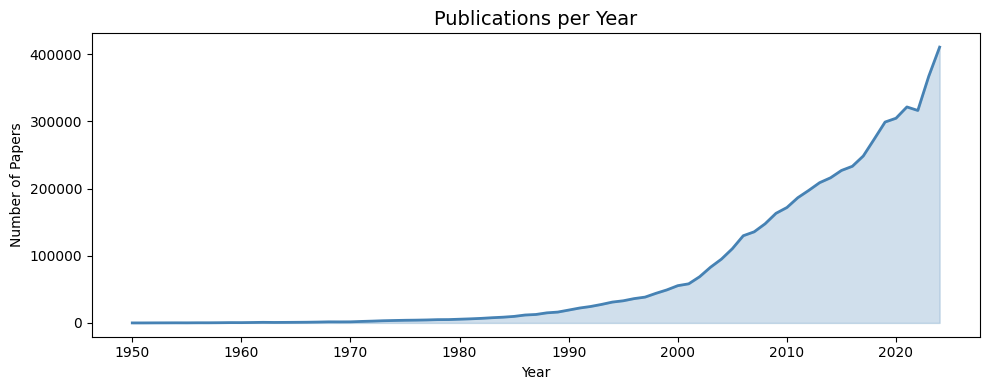

In [7]:
df_year = con.sql(f"""
    SELECT year, COUNT(*) AS papers
    FROM papers
    WHERE year BETWEEN 1950 AND 2024
    GROUP BY year
    ORDER BY year
""").df()
 
fig, ax = plt.subplots(figsize=(10,4))
ax.fill_between(df_year["year"], df_year["papers"], alpha=0.25, color="steelblue")
ax.plot(df_year["year"], df_year["papers"], color="steelblue", linewidth=2)
ax.set_title("Publications per Year", fontsize=14)
ax.set_xlabel("Year")
ax.set_ylabel("Number of Papers")

plt.tight_layout()
plt.show()
 

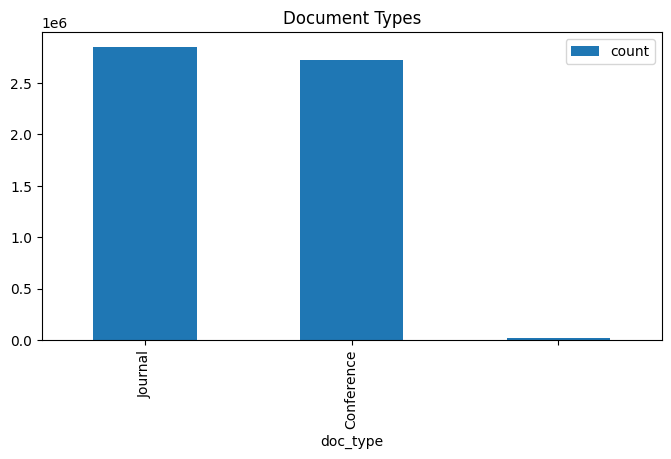

In [8]:
df = con.sql(f"""
    SELECT doc_type, COUNT(*) AS count
    FROM papers
    WHERE doc_type IS NOT NULL
    GROUP BY doc_type ORDER BY count DESC
""").df()

df.plot(kind="bar", x="doc_type", y="count", title="Document Types", figsize=(8,4))
plt.show()

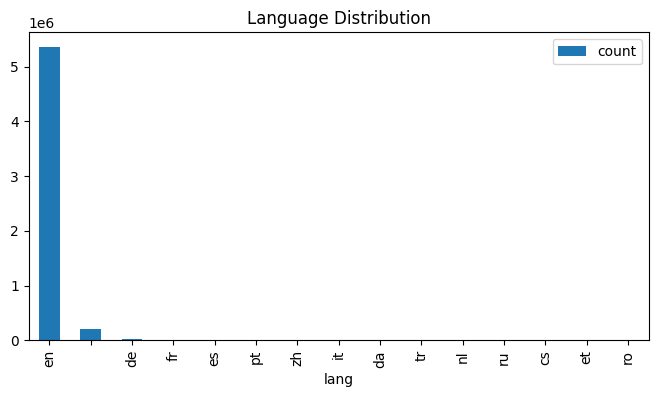

In [9]:
df = con.sql(f"""
    SELECT lang, COUNT(*) AS count
    FROM papers
    WHERE lang IS NOT NULL
    GROUP BY lang ORDER BY count DESC
    LIMIT 15
""").df()

df.plot(kind="bar", x="lang", y="count", title="Language Distribution", figsize=(8,4))
plt.show()

## Citation Analysis

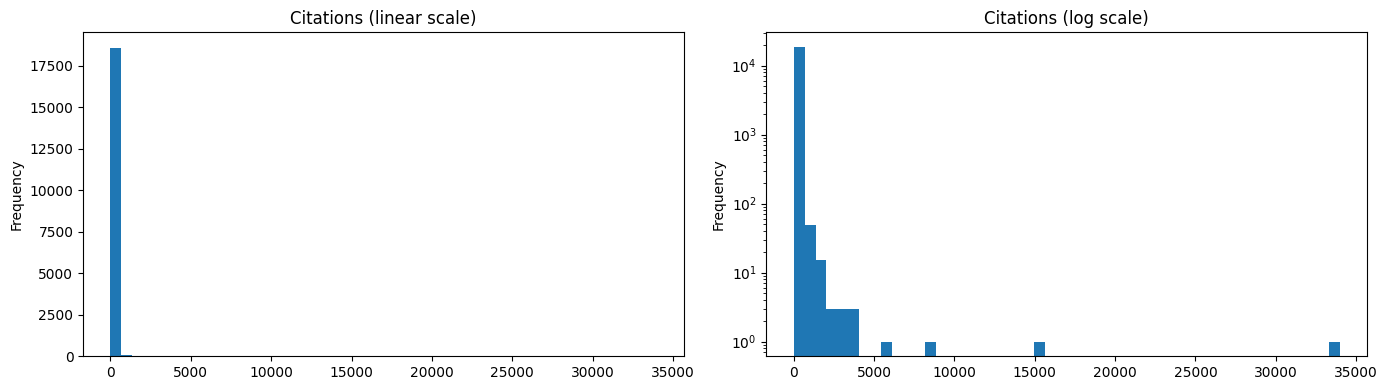

In [10]:
df = con.sql(f"""
    SELECT n_citation
    FROM papers
    WHERE n_citation IS NOT NULL AND n_citation > 0
    USING SAMPLE 20000
""").df()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df["n_citation"].plot(kind="hist", bins=50, ax=axes[0], title="Citations (linear scale)")
df["n_citation"].apply(lambda x: x+1).plot(kind="hist", bins=50, logy=True, ax=axes[1], title="Citations (log scale)")
plt.tight_layout()
plt.show()

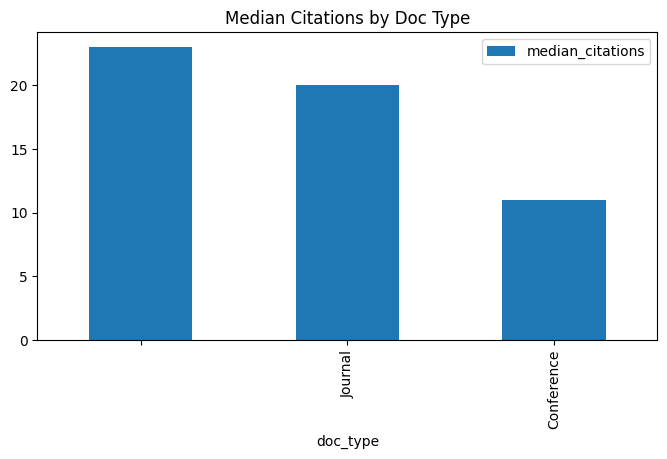

In [11]:
df = con.sql(f"""
    SELECT doc_type,
           COUNT(*) AS papers,
           AVG(n_citation) AS avg_citations,
           MEDIAN(n_citation) AS median_citations
    FROM read_parquet('{PARQUET}')
    WHERE doc_type IS NOT NULL AND n_citation IS NOT NULL
    GROUP BY doc_type ORDER BY median_citations DESC
""").df()

df.plot(kind="bar", x="doc_type", y="median_citations", title="Median Citations by Doc Type", figsize=(8,4))
plt.show()

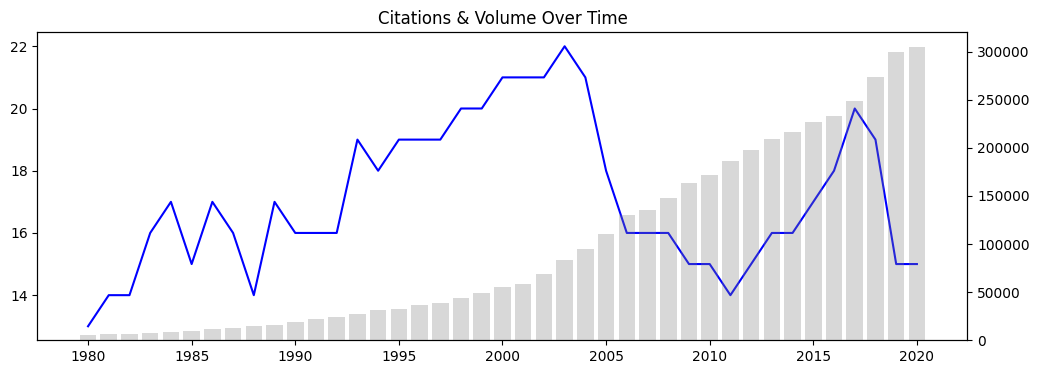

In [12]:
df = con.sql(f"""
    SELECT year,
           MEDIAN(n_citation) AS median_citations,
           COUNT(*) AS papers
    FROM papers
    WHERE year BETWEEN 1980 AND 2020 AND n_citation IS NOT NULL
    GROUP BY year ORDER BY year
""").df()

fig, ax1 = plt.subplots(figsize=(12, 4))
ax2 = ax1.twinx()
ax1.plot(df["year"], df["median_citations"], color="blue", label="Median citations")
ax2.bar(df["year"], df["papers"], alpha=0.3, color="gray", label="Paper count")
ax1.set_title("Citations & Volume Over Time")
plt.show()

## Authors and Collaborations

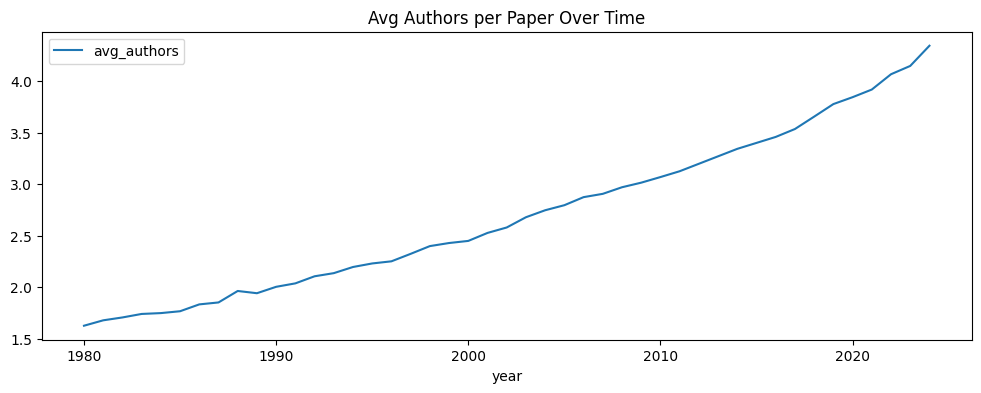

In [13]:
df = con.sql(f"""
    SELECT year,
           AVG(ARRAY_LENGTH(authors)) AS avg_authors
    FROM papers
    WHERE year BETWEEN 1980 AND 2024 AND authors IS NOT NULL
    GROUP BY year ORDER BY year
""").df()

df.plot(kind="line", x="year", y="avg_authors", title="Avg Authors per Paper Over Time", figsize=(12,4))
plt.show()

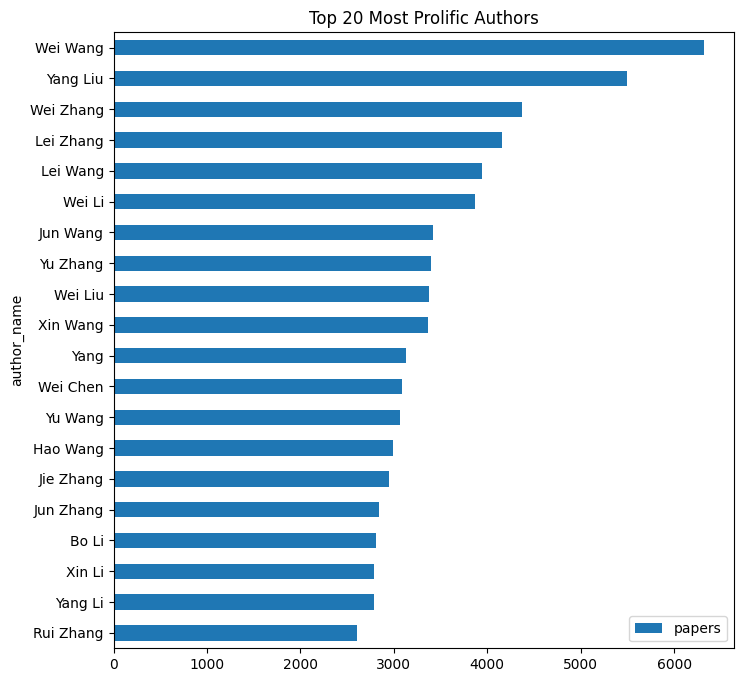

In [14]:
df = con.sql(f"""
    SELECT
        author.name AS author_name,
        COUNT(*) AS papers
    FROM papers
    CROSS JOIN UNNEST(authors) AS t(author)
    WHERE author.name IS NOT NULL
      AND author.name != ''
    GROUP BY 1
    ORDER BY papers DESC
    LIMIT 20
""").df()

df.plot(kind="barh", x="author_name", y="papers", title="Top 20 Most Prolific Authors", figsize=(8,8))
plt.gca().invert_yaxis()
plt.show()

## Keywords and Venues

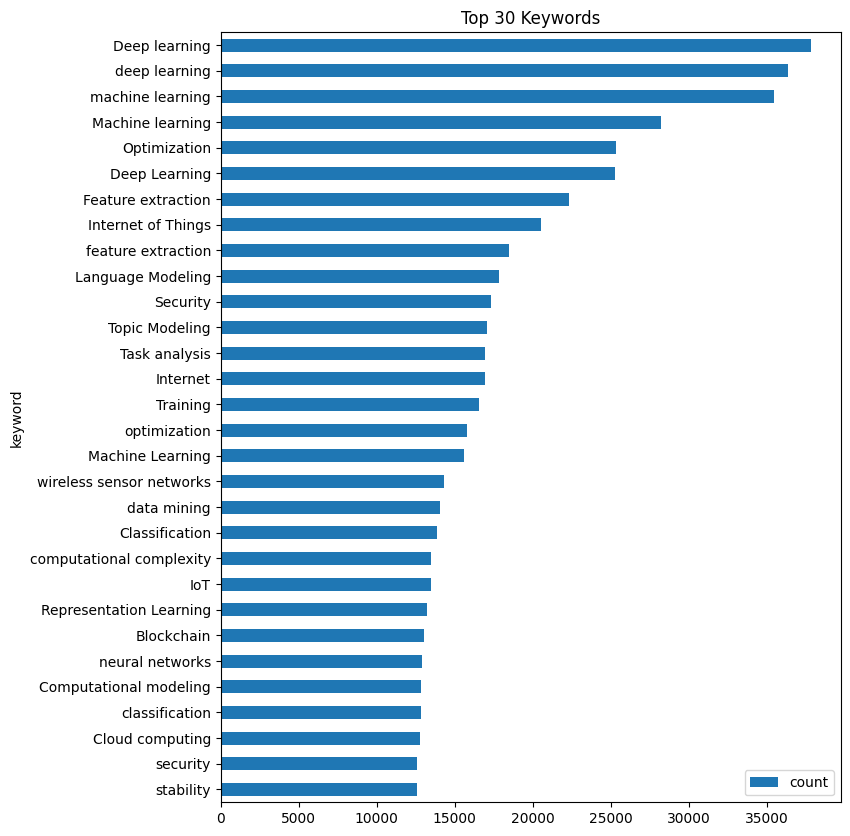

In [15]:
df = con.sql(f"""
    SELECT kw AS keyword, COUNT(*) AS count
    FROM papers
    CROSS JOIN UNNEST(keywords) AS t(kw)
    WHERE kw IS NOT NULL AND kw != ''
    GROUP BY kw
    ORDER BY count DESC
    LIMIT 30
""").df()

df.plot(kind="barh", x="keyword", y="count", title="Top 30 Keywords", figsize=(8,10))
plt.gca().invert_yaxis()
plt.show()

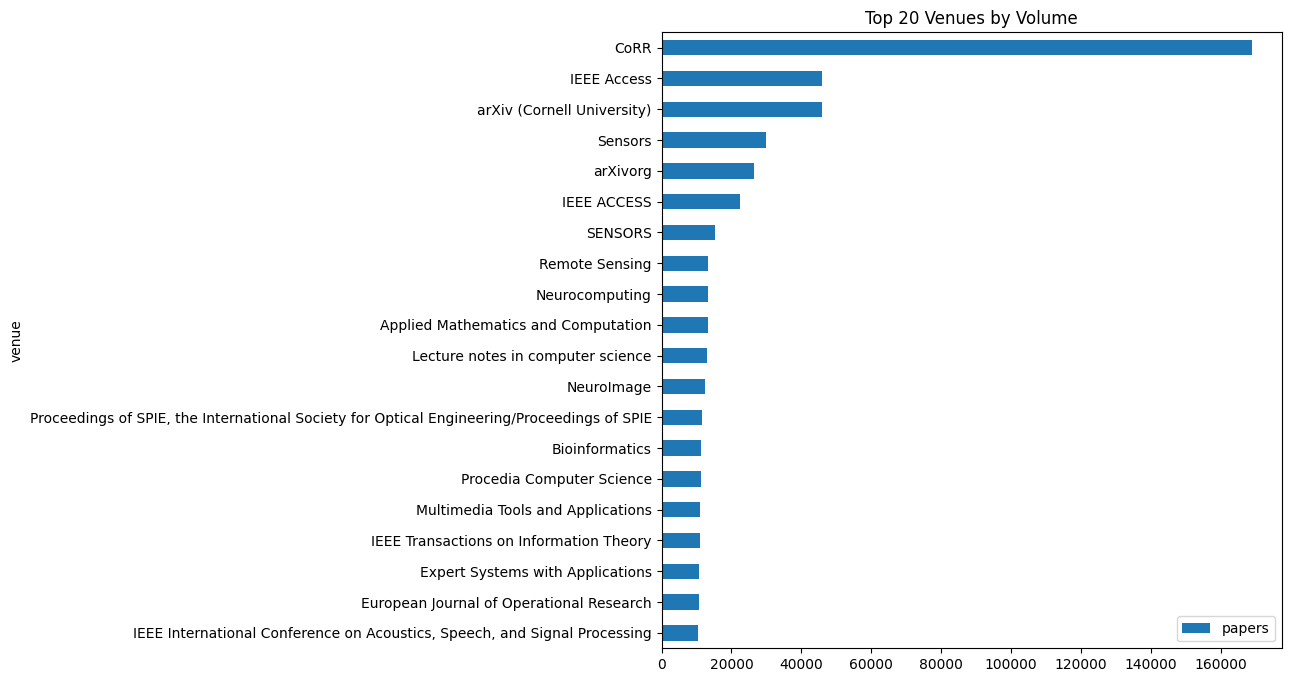

In [16]:
df = con.sql(f"""
    SELECT venue, COUNT(*) AS papers, MEDIAN(n_citation) AS median_citations
    FROM papers
    WHERE venue IS NOT NULL AND venue != ''
    GROUP BY venue
    ORDER BY papers DESC
    LIMIT 20
""").df()

df.plot(kind="barh", x="venue", y="papers", title="Top 20 Venues by Volume", figsize=(8,8))
plt.gca().invert_yaxis()
plt.show()

##  Missingness

In [17]:
# Missingness report (null + empty string/array) on stable table `papers`
missing_df = con.sql("""
WITH base AS (
    SELECT
        COUNT(*)::DOUBLE AS total_rows,
        SUM(CASE WHEN id IS NULL OR TRIM(COALESCE(id, '')) = '' THEN 1 ELSE 0 END) AS miss_id,
        SUM(CASE WHEN title IS NULL OR TRIM(COALESCE(title, '')) = '' THEN 1 ELSE 0 END) AS miss_title,
        SUM(CASE WHEN abstract IS NULL OR TRIM(COALESCE(abstract, '')) = '' THEN 1 ELSE 0 END) AS miss_abstract,
        SUM(CASE WHEN keywords IS NULL OR ARRAY_LENGTH(keywords) = 0 THEN 1 ELSE 0 END) AS miss_keywords,
        SUM(CASE WHEN year IS NULL THEN 1 ELSE 0 END) AS miss_year,
        SUM(CASE WHEN authors IS NULL OR ARRAY_LENGTH(authors) = 0 THEN 1 ELSE 0 END) AS miss_authors,
        SUM(CASE WHEN "references" IS NULL OR ARRAY_LENGTH("references") = 0 THEN 1 ELSE 0 END) AS miss_references,
        SUM(CASE WHEN lang IS NULL OR TRIM(COALESCE(lang, '')) = '' THEN 1 ELSE 0 END) AS miss_lang,
        SUM(CASE WHEN venue IS NULL OR TRIM(COALESCE(venue, '')) = '' THEN 1 ELSE 0 END) AS miss_venue,
        SUM(CASE WHEN doc_type IS NULL OR TRIM(COALESCE(doc_type, '')) = '' THEN 1 ELSE 0 END) AS miss_doc_type,
        SUM(CASE WHEN doi IS NULL OR TRIM(COALESCE(doi, '')) = '' THEN 1 ELSE 0 END) AS miss_doi,
        SUM(CASE WHEN page_start IS NULL OR TRIM(COALESCE(page_start, '')) = '' THEN 1 ELSE 0 END) AS miss_page_start,
        SUM(CASE WHEN page_end IS NULL OR TRIM(COALESCE(page_end, '')) = '' THEN 1 ELSE 0 END) AS miss_page_end,
        SUM(CASE WHEN n_citation IS NULL THEN 1 ELSE 0 END) AS miss_n_citation
    FROM papers
)
SELECT * FROM (
    SELECT 'id' AS feature,        100.0 * miss_id / total_rows AS missing_pct FROM base
    UNION ALL SELECT 'title',      100.0 * miss_title / total_rows FROM base
    UNION ALL SELECT 'abstract',   100.0 * miss_abstract / total_rows FROM base
    UNION ALL SELECT 'keywords',   100.0 * miss_keywords / total_rows FROM base
    UNION ALL SELECT 'year',       100.0 * miss_year / total_rows FROM base
    UNION ALL SELECT 'authors',    100.0 * miss_authors / total_rows FROM base
    UNION ALL SELECT 'references', 100.0 * miss_references / total_rows FROM base
    UNION ALL SELECT 'lang',       100.0 * miss_lang / total_rows FROM base
    UNION ALL SELECT 'venue',      100.0 * miss_venue / total_rows FROM base
    UNION ALL SELECT 'doc_type',   100.0 * miss_doc_type / total_rows FROM base
    UNION ALL SELECT 'doi',        100.0 * miss_doi / total_rows FROM base
    UNION ALL SELECT 'page_start', 100.0 * miss_page_start / total_rows FROM base
    UNION ALL SELECT 'page_end',   100.0 * miss_page_end / total_rows FROM base
    UNION ALL SELECT 'n_citation', 100.0 * miss_n_citation / total_rows FROM base
)
ORDER BY missing_pct DESC
""").df()

display(missing_df)

,feature,missing_pct
0,page_end,27.980626
1,page_start,26.567562
2,keywords,16.174596
3,references,15.663837
4,doi,8.936097
5,abstract,5.378904
6,lang,3.593752
7,venue,0.661200
8,doc_type,0.308573
9,authors,0.000036


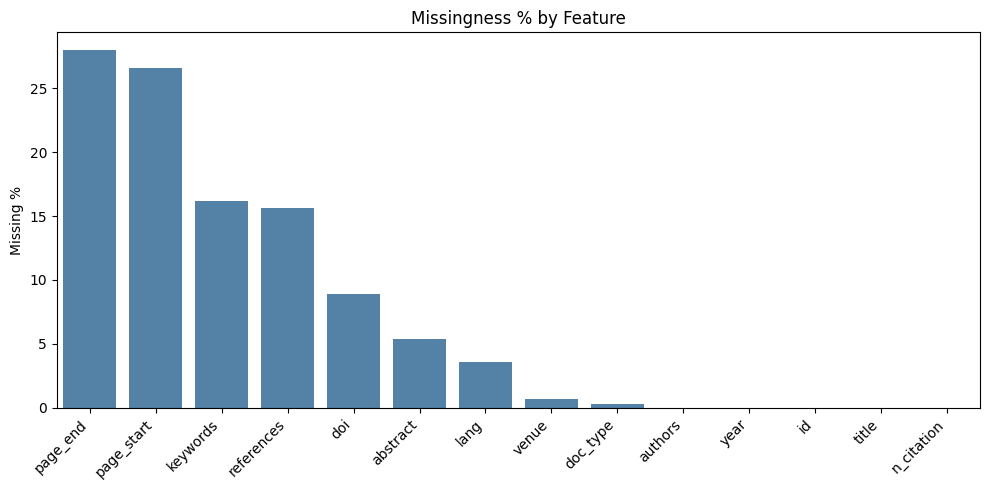

In [18]:
plt.figure(figsize=(10, 5))
sns.barplot(data=missing_df, x="feature", y="missing_pct", color="steelblue")
plt.title("Missingness % by Feature")
plt.ylabel("Missing %")
plt.xlabel("")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Data Quality

In [19]:
df = con.sql(f"""
    SELECT
        COUNT(*) AS total,
        COUNT(title) AS has_title,
        COUNT(abstract) AS has_abstract,
        COUNT(year) AS has_year,
        COUNT(doi) AS has_doi,
        COUNT(n_citation) AS has_citations,
        COUNT(venue) AS has_venue
    FROM papers
""").df()

print(df.T)

                     0
total          5590897
has_title      5590897
has_abstract   5590897
has_year       5590897
has_doi        5590897
has_citations  5590897
has_venue      5568934


### Correlation Matrix

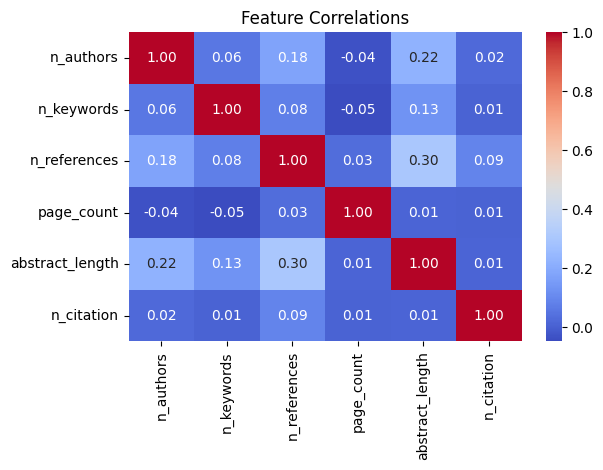

In [20]:
df = con.sql(f"""
    SELECT
        ARRAY_LENGTH(authors) AS n_authors,
        ARRAY_LENGTH(keywords) AS n_keywords,
        ARRAY_LENGTH("references") AS n_references,
        TRY_CAST(page_end AS INT) - TRY_CAST(page_start AS INT) AS page_count,
        LENGTH(abstract) AS abstract_length,
        n_citation
    FROM papers
    WHERE n_citation IS NOT NULL
    USING SAMPLE 20000
""").df().dropna()

sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlations")
plt.tight_layout()
plt.show()

## Features selection